# 7115 Portfolio IMU Notebook

## Walking

In [ ]:

#%%
from scipy.spatial.transform import Rotation as R
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df=pd.read_csv(r"Assets/Walking-1_TS-03155_2026-02-20-12-10-14_aligned.csv")
df2=pd.read_csv(r"Assets/Walking-1_TS-03379_2026-02-20-12-10-14_aligned.csv")

# %%
shank= df[['qx','qy','qz','qr']].values
thigh= df2[['qx','qy','qz','qr']].values

min_len = min(len(thigh), len(shank))

thigh = thigh[:min_len]
shank = shank[:min_len]
# %%
r1=R.from_quat(thigh)

# %%
r2=R.from_quat(shank)

#%%
static_frames= 500

r_thigh_static=r1[:static_frames]
r_shank_static=r2[:static_frames]

r_offset=(r_thigh_static.inv() * r_shank_static).mean()
# %%
r_knee=r1.inv() * r2 
r_knee_corrected=r_knee * r_offset.inv()
# %%
euler_knee=r_knee_corrected.as_euler('xyz', degrees=True)
plt.plot(euler_knee[:,0], label='X-axis')
plt.plot(euler_knee[:,1], label='Y-axis')
plt.plot(euler_knee[:,2], label='Z-axis')
plt.legend()

plt.show()


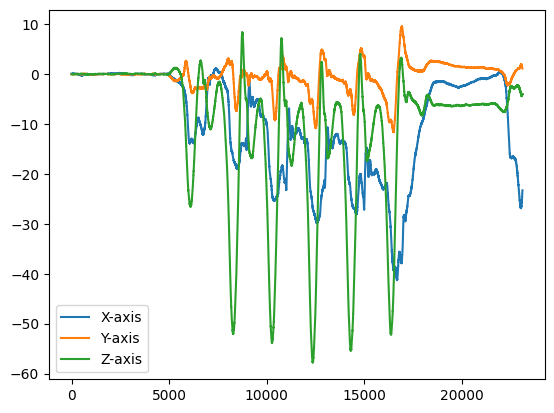

### What I learned:
- Make Sure you note which number IMU corresponds to which segment to properly label the 
data frames when they are loaded into python.

- Time synchronised does not necessarilly mean length will be the same. Have to trim to the 
length of the shortest file with min(len(seg1),len(seg2)).

- scipy.spatial.transform Rotation allows for conversion of quat to rotation matrix
as long as quats are in format [x y z w] where x,y and z are sensor axes and w is a scalar.

- The participant needs to stand still before motion to establish a static period. 
The static period is used to create an offset which informs the relative orientations
of the sensors when joint angle is neutral (such as standing). 

- Uncorrected joint angle is computed by multiplying the inverse of the proximal joint's 
rotation matrix by the distal joint's rotation matrix.  Using the inverse "wipes" the 
global frames contribution, resulting in relative rotation.

- This uncorrected joint angle is than multiplied by the previously calculated offset
in order to get the corrected joint angle relative to standing (neutral). 

- The rotation matrix can now be converted to euler rotations using a sepcified order
of rotations to return joint angles. 

### Issues I encountered: 
- Based on my understanding of what the sagittal plane knee joint curve should look like during normal gait, the z axis appears to be flexion and extension. Why is this? 
- The sensors axes are determining dominant actions. The sensor is aligned such that x is 
along the long axis of the segment, y in the direction of walking, and z orthogonal to these
completing the right hand rule. 

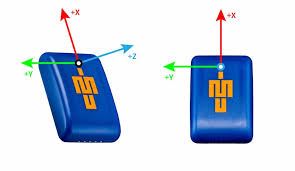

- Why do X and Y look strange? 
= Appears to be  drifitng of the x axis (not determined to be knee joint rotation) to larger negative values, and  increasing y axis magnitude  over the course of the trial. Appears to be 
suggestive of potential skin artefact or crosstalk. I intend to speak with someone familiar 
with these issues about why the graph looks like this. 

### Whats next: 
- I understand the basis behind IMU calaculation, particularily reading in data, extracting
Quats, and using them in calcualation. I understan that the basis of calculations relies on
calculating offset before movement using the inverse of the proximal segment multiplied
by the distal segment while static. Than after this, getting the uncorrected knee joint angle
and using the offset to correct it. I see how this could be done in a longer script spanning
multiple joints, and feel I am ready to move onto more full body movements. 

## Functional movements
For the functional movements I had placed IMUs on a participants pelvis, thighs, shank, and feet. I had the participant first complete a trial where they flexed each knee three times, than abducted each leg three times. In a separate trial I than had them complete 2 body weight squats. In a final trial I had them complete one lunge on each leg. During this final trial I had a sensor drop out, and was not able to get a full data set. 

I than used the same general idea I learned to calcualte knee joint angle during walking, but applied it to all the lower body joints across both the functional movments and squatting trials. 






In [ ]:
# %%

root_dir= Path(__file__).resolve().parent
data_dir= root_dir/'Assets'



def load_data():
    trials={}
    for file in data_dir.rglob(r"*.csv"):

        parts= file.stem.split('_')
        if len(parts)==2:
            condition, joint= parts [0],parts[1]
            side='none'
        elif len(parts)==3:
            condition, side, joint= parts [0],parts[1], parts[2]
        else:
            print(f"Skipping unexpected filename: {file.name}")
            continue


        meta_data= pd.read_csv(file)

        quat_cols = ['qx', 'qy', 'qz', 'qr']
        if not all(col in meta_data.columns for col in quat_cols):
            print(f"Skipping {file.name}: missing quaternion columns")
            continue

        quats = meta_data[quat_cols]

        trials.setdefault(condition, {}).setdefault(joint, {})[side] = quats

    return trials
trials=load_data()
#%% Joint function
def calculate_joint_angles(trials, condition, proximal, distal, static_frames=500):
    prox_side, prox_seg = proximal.split('/')
    dist_side, dist_seg = distal.split('/')
    
    q_prox = trials[condition][prox_seg][prox_side][['qx', 'qy', 'qz', 'qr']].values
    q_dist = trials[condition][dist_seg][dist_side][['qx', 'qy', 'qz', 'qr']].values
    
    # trim to same length
    min_len = min(len(q_prox), len(q_dist))
    q_prox = q_prox[:min_len]
    q_dist = q_dist[:min_len]
    
    r_prox = R.from_quat(q_prox)
    r_dist = R.from_quat(q_dist)
    
    # static offset correction
    r_offset = (r_prox[:static_frames].inv() * r_dist[:static_frames]).mean()
    
    # joint angle
    r_joint = r_prox.inv() * r_dist
    r_joint_corrected = r_joint * r_offset.inv()
    
    euler = r_joint_corrected.as_euler('xyz', degrees=True)
    
    return euler

joints = {
    'left_knee':  ('L/thigh',  'L/shank'),
    'right_knee': ('R/thigh', 'R/shank'),
    'left_hip':   ('none/pelvis', 'L/thigh'),
    'right_hip':  ('none/pelvis', 'R/thigh'),
    'left_ankle': ('L/shank',  'L/foot'),
    'right_ankle':('R/shank', 'R/foot'),
}

conditions= ['squat', 'functional']

results = {}

for condition in conditions:
    results[condition]={}
    for joint_name, (proximal, distal) in joints.items():
        try:
            results[condition][joint_name] = calculate_joint_angles(
                trials, condition, proximal, distal
                )
        except KeyError:
            print(f"missing data for {condition}-{joint_name},skipping")

One error I found here was that the flexion signs were flipped. As a results I added some code at the end of the pipeline to correct this by flipping the sign in the dataframe. 





In [ ]:
results['functional']['right_knee'][:,2] *= -1
results['squat']['right_knee'][:,2] *= -1

I than plotted each trial, specifically the knee flexion angles and hip ab/adduction in the functional movement trial, and the knee flexion angles in the squatting trial. 
### functional movements
![alt text](image.png)
### squatting
![alt text](image-1.png)
